In [1]:
pwd

'C:\\Users\\RENUKA\\Documents\\Task\\Notes\\Indigo\\Flight_Delay_Prediction\\Notebooks'

In [2]:
import pandas as pd

# Load the flight dataset
df = pd.read_csv("../data/flights.csv")

# Display first 5 rows
df.head()

C:\Users\RENUKA\AppData\Local\Temp\ipykernel_23396\2582372214.py:4: DtypeWarning: Columns (7,8) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../data/flights.csv")


,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,...,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY
0,2015,1,1,4,AS,98,N407AS,ANC,SEA,5,...,408.0,-22.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
1,2015,1,1,4,AA,2336,N3KUAA,LAX,PBI,10,...,741.0,-9.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
2,2015,1,1,4,US,840,N171US,SFO,CLT,20,...,811.0,5.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
3,2015,1,1,4,AA,258,N3HYAA,LAX,MIA,20,...,756.0,-9.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,2015,1,1,4,AS,135,N527AS,SEA,ANC,25,...,259.0,-21.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

df.info()

Rows: 5819079
Columns: 31
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5819079 entries, 0 to 5819078
Data columns (total 31 columns):
 #   Column               Dtype  
---  ------               -----  
 0   YEAR                 int64  
 1   MONTH                int64  
 2   DAY                  int64  
 3   DAY_OF_WEEK          int64  
 4   AIRLINE              object 
 5   FLIGHT_NUMBER        int64  
 6   TAIL_NUMBER          object 
 7   ORIGIN_AIRPORT       object 
 8   DESTINATION_AIRPORT  object 
 9   SCHEDULED_DEPARTURE  int64  
 10  DEPARTURE_TIME       float64
 11  DEPARTURE_DELAY      float64
 12  TAXI_OUT             float64
 13  WHEELS_OFF           float64
 14  SCHEDULED_TIME       float64
 15  ELAPSED_TIME         float64
 16  AIR_TIME             float64
 17  DISTANCE             int64  
 18  WHEELS_ON            float64
 19  TAXI_IN              float64
 20  SCHEDULED_ARRIVAL    int64  
 21  ARRIVAL_TIME         float64
 22  ARRIVAL_DELAY        float64
 23  DIVERT

In [4]:
df.columns.tolist()

['YEAR',
 'MONTH',
 'DAY',
 'DAY_OF_WEEK',
 'AIRLINE',
 'FLIGHT_NUMBER',
 'TAIL_NUMBER',
 'ORIGIN_AIRPORT',
 'DESTINATION_AIRPORT',
 'SCHEDULED_DEPARTURE',
 'DEPARTURE_TIME',
 'DEPARTURE_DELAY',
 'TAXI_OUT',
 'WHEELS_OFF',
 'SCHEDULED_TIME',
 'ELAPSED_TIME',
 'AIR_TIME',
 'DISTANCE',
 'WHEELS_ON',
 'TAXI_IN',
 'SCHEDULED_ARRIVAL',
 'ARRIVAL_TIME',
 'ARRIVAL_DELAY',
 'DIVERTED',
 'CANCELLED',
 'CANCELLATION_REASON',
 'AIR_SYSTEM_DELAY',
 'SECURITY_DELAY',
 'AIRLINE_DELAY',
 'LATE_AIRCRAFT_DELAY',
 'WEATHER_DELAY']

In [6]:
df.head()

,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,...,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY
0,2015,1,1,4,AS,98,N407AS,ANC,SEA,5,...,408.0,-22.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
1,2015,1,1,4,AA,2336,N3KUAA,LAX,PBI,10,...,741.0,-9.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
2,2015,1,1,4,US,840,N171US,SFO,CLT,20,...,811.0,5.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
3,2015,1,1,4,AA,258,N3HYAA,LAX,MIA,20,...,756.0,-9.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,2015,1,1,4,AS,135,N527AS,SEA,ANC,25,...,259.0,-21.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
# Check missing values
missing = df.isnull().sum()

missing_df = pd.DataFrame({
    "Missing_Count": missing,
    "Missing_Percentage": (missing / len(df) * 100).round(2)
})

missing_df.sort_values("Missing_Percentage", ascending=False)

,Missing_Count,Missing_Percentage
CANCELLATION_REASON,5729195,98.46
WEATHER_DELAY,4755640,81.72
LATE_AIRCRAFT_DELAY,4755640,81.72
AIRLINE_DELAY,4755640,81.72
SECURITY_DELAY,4755640,81.72
AIR_SYSTEM_DELAY,4755640,81.72
AIR_TIME,105071,1.81
ARRIVAL_DELAY,105071,1.81
ELAPSED_TIME,105071,1.81
WHEELS_ON,92513,1.59


In [8]:
# Basic statistics for important numerical columns
df[
    [
        "DEPARTURE_DELAY",
        "ARRIVAL_DELAY",
        "SCHEDULED_TIME",
        "DISTANCE"
    ]
].describe()

,DEPARTURE_DELAY,ARRIVAL_DELAY,SCHEDULED_TIME,DISTANCE
count,5.732926e+06,5.714008e+06,5.819073e+06,5.819079e+06
mean,9.370158e+00,4.407057e+00,1.416859e+02,8.223565e+02
std,3.708094e+01,3.927130e+01,7.521058e+01,6.077843e+02
min,-8.200000e+01,-8.700000e+01,1.800000e+01,2.100000e+01
25%,-5.000000e+00,-1.300000e+01,8.500000e+01,3.730000e+02
50%,-2.000000e+00,-5.000000e+00,1.230000e+02,6.470000e+02
75%,7.000000e+00,8.000000e+00,1.730000e+02,1.062000e+03
max,1.988000e+03,1.971000e+03,7.180000e+02,4.983000e+03


In [9]:
# Check unique values in important categorical columns
print("Airlines:", df["AIRLINE"].nunique())
print("Origin airports:", df["ORIGIN_AIRPORT"].nunique())
print("Destination airports:", df["DESTINATION_AIRPORT"].nunique())

Airlines: 14
Origin airports: 930
Destination airports: 930


In [10]:
print("Cancelled flights:", df["CANCELLED"].sum())
print("Diverted flights:", df["DIVERTED"].sum())

print("\nCancelled %:",
      round(df["CANCELLED"].mean() * 100, 2), "%")

print("Diverted %:",
      round(df["DIVERTED"].mean() * 100, 2), "%")

Cancelled flights: 89884
Diverted flights: 15187

Cancelled %: 1.54 %
Diverted %: 0.26 %


In [11]:
print(pd.crosstab(df["CANCELLED"], df["DIVERTED"]))

DIVERTED         0      1
CANCELLED                
0          5714008  15187
1            89884      0


In [12]:
df[df["CANCELLED"] == 1][
    ["YEAR", "MONTH", "DAY", "AIRLINE",
     "ORIGIN_AIRPORT", "DESTINATION_AIRPORT",
     "CANCELLED", "CANCELLATION_REASON"]
].head(10)

,YEAR,MONTH,DAY,AIRLINE,ORIGIN_AIRPORT,DESTINATION_AIRPORT,CANCELLED,CANCELLATION_REASON
32,2015,1,1,AS,ANC,SEA,1,A
42,2015,1,1,AA,PHX,DFW,1,B
68,2015,1,1,OO,MAF,IAH,1,B
82,2015,1,1,MQ,SGF,DFW,1,B
90,2015,1,1,OO,RDD,SFO,1,A
128,2015,1,1,MQ,CHS,DFW,1,B
131,2015,1,1,OO,SMX,LAX,1,A
147,2015,1,1,MQ,ABI,DFW,1,B
166,2015,1,1,MQ,XNA,DFW,1,B
206,2015,1,1,AA,DCA,DFW,1,B


6.1 Create the clean dataset

In [13]:
model_df = df[
    (df["CANCELLED"] == 0) &
    (df["DIVERTED"] == 0) &
    (df["ARRIVAL_DELAY"].notna())
].copy()

print("Original rows:", len(df))
print("Modeling rows:", len(model_df))
print("Rows removed:", len(df) - len(model_df))

Original rows: 5819079
Modeling rows: 5714008
Rows removed: 105071


6.2 Create our Target

In [14]:
model_df["IS_DELAYED"] = (
    model_df["ARRIVAL_DELAY"] > 15
).astype(int)

In [15]:
print(model_df["IS_DELAYED"].value_counts())

print("\nDelay percentage:")
print(model_df["IS_DELAYED"].value_counts(normalize=True) * 100)

IS_DELAYED
0    4690510
1    1023498
Name: count, dtype: int64

Delay percentage:
IS_DELAYED
0    82.087914
1    17.912086
Name: proportion, dtype: float64


EDA

Flight Delay Distribution

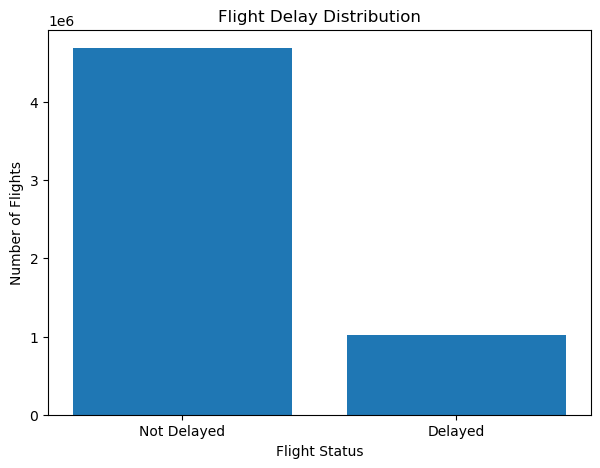

In [16]:
import matplotlib.pyplot as plt

delay_counts = model_df["IS_DELAYED"].value_counts().sort_index()

plt.figure(figsize=(7, 5))
plt.bar(["Not Delayed", "Delayed"], delay_counts.values)

plt.title("Flight Delay Distribution")
plt.xlabel("Flight Status")
plt.ylabel("Number of Flights")

plt.show()

Delay percentage by airline

In [17]:
airline_delay = (
    model_df.groupby("AIRLINE")["IS_DELAYED"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

print(airline_delay)

AIRLINE
NK    28.791680
F9    25.364635
B6    21.850314
MQ    21.027580
UA    19.950883
EV    18.987043
VX    18.527952
WN    18.296559
OO    18.004071
US    17.984482
AA    17.566538
DL    12.997271
AS    12.343749
HA    10.533791
Name: IS_DELAYED, dtype: float64


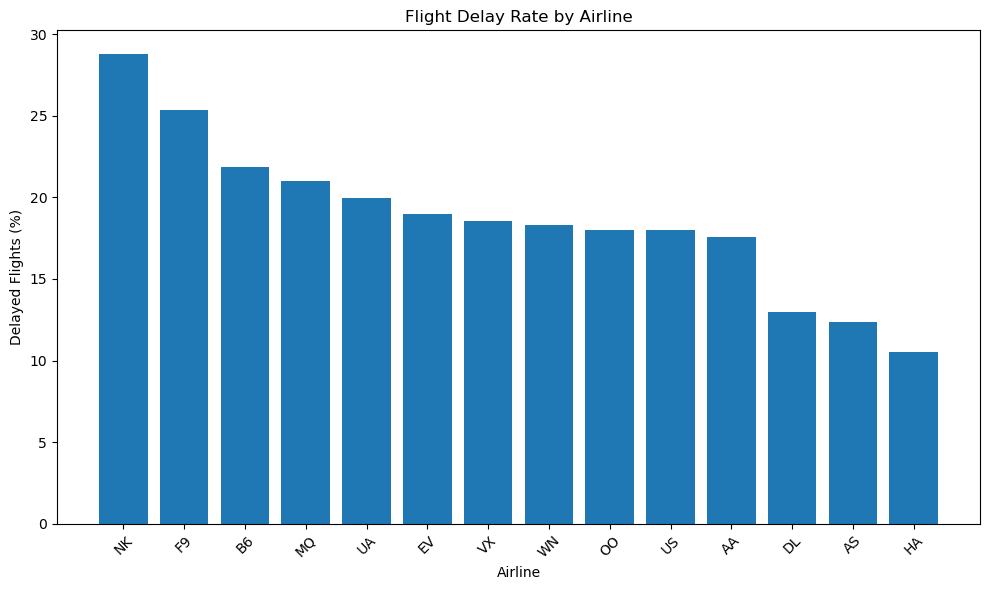

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.bar(
    airline_delay.index,
    airline_delay.values
)

plt.title("Flight Delay Rate by Airline")
plt.xlabel("Airline")
plt.ylabel("Delayed Flights (%)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [19]:
airlines = pd.read_csv("../data/airlines.csv")

airlines

,IATA_CODE,AIRLINE
0,UA,United Air Lines Inc.
1,AA,American Airlines Inc.
2,US,US Airways Inc.
3,F9,Frontier Airlines Inc.
4,B6,JetBlue Airways
5,OO,Skywest Airlines Inc.
6,AS,Alaska Airlines Inc.
7,NK,Spirit Air Lines
8,WN,Southwest Airlines Co.
9,DL,Delta Air Lines Inc.


Create the airline delay table

In [20]:
airline_delay = (
    model_df.groupby("AIRLINE")["IS_DELAYED"]
    .mean()
    .mul(100)
    .reset_index(name="DELAY_RATE")
)

airline_delay

,AIRLINE,DELAY_RATE
0,AA,17.566538
1,AS,12.343749
2,B6,21.850314
3,DL,12.997271
4,EV,18.987043
5,F9,25.364635
6,HA,10.533791
7,MQ,21.027580
8,NK,28.791680
9,OO,18.004071


In [21]:
airline_delay = airline_delay.merge(
    airlines,
    left_on="AIRLINE",
    right_on="IATA_CODE"
)

airline_delay = airline_delay.sort_values(
    "DELAY_RATE",
    ascending=False
)

airline_delay

,AIRLINE_x,DELAY_RATE,IATA_CODE,AIRLINE_y
8,NK,28.791680,NK,Spirit Air Lines
5,F9,25.364635,F9,Frontier Airlines Inc.
2,B6,21.850314,B6,JetBlue Airways
7,MQ,21.027580,MQ,American Eagle Airlines Inc.
10,UA,19.950883,UA,United Air Lines Inc.
4,EV,18.987043,EV,Atlantic Southeast Airlines
12,VX,18.527952,VX,Virgin America
13,WN,18.296559,WN,Southwest Airlines Co.
9,OO,18.004071,OO,Skywest Airlines Inc.
11,US,17.984482,US,US Airways Inc.


In [23]:
airline_delay.columns

Index(['AIRLINE_x', 'DELAY_RATE', 'IATA_CODE', 'AIRLINE_y'], dtype='object')

In [24]:
airline_delay = airline_delay.rename(
    columns={
        "AIRLINE_x": "IATA_CODE",
        "AIRLINE_y": "AIRLINE_NAME"
    }
)

airline_delay

,IATA_CODE,DELAY_RATE,IATA_CODE,AIRLINE_NAME
8,NK,28.791680,NK,Spirit Air Lines
5,F9,25.364635,F9,Frontier Airlines Inc.
2,B6,21.850314,B6,JetBlue Airways
7,MQ,21.027580,MQ,American Eagle Airlines Inc.
10,UA,19.950883,UA,United Air Lines Inc.
4,EV,18.987043,EV,Atlantic Southeast Airlines
12,VX,18.527952,VX,Virgin America
13,WN,18.296559,WN,Southwest Airlines Co.
9,OO,18.004071,OO,Skywest Airlines Inc.
11,US,17.984482,US,US Airways Inc.


Create the professional chart

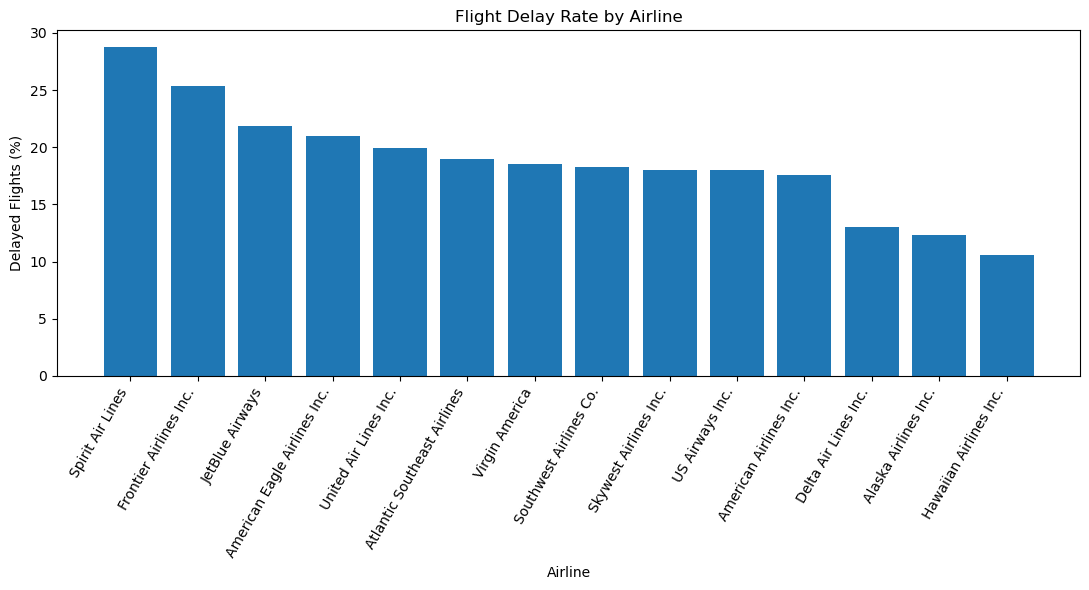

In [25]:

plt.figure(figsize=(11, 6))

plt.bar(
    airline_delay["AIRLINE_NAME"],
    airline_delay["DELAY_RATE"]
)

plt.title("Flight Delay Rate by Airline")
plt.xlabel("Airline")
plt.ylabel("Delayed Flights (%)")

plt.xticks(rotation=60, ha="right")

plt.tight_layout()
plt.show()

Delay rate by day of the week

In [26]:
day_delay = (
    model_df.groupby("DAY_OF_WEEK")["IS_DELAYED"]
    .mean()
    .mul(100)
)

print(day_delay)

DAY_OF_WEEK
1    19.069867
2    17.614839
3    17.501975
4    19.252558
5    18.433920
6    15.376842
7    17.627452
Name: IS_DELAYED, dtype: float64


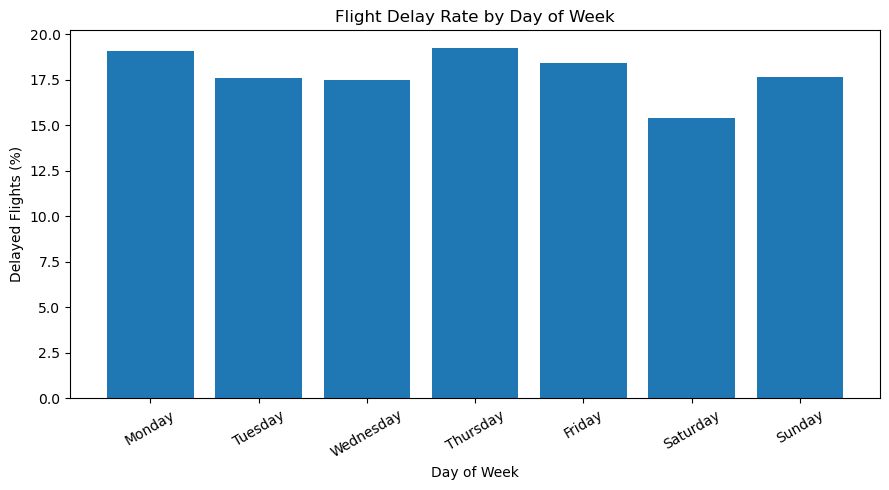

In [27]:
day_names = {
    1: "Monday",
    2: "Tuesday",
    3: "Wednesday",
    4: "Thursday",
    5: "Friday",
    6: "Saturday",
    7: "Sunday"
}

day_delay_named = day_delay.rename(index=day_names)

plt.figure(figsize=(9, 5))

plt.bar(
    day_delay_named.index,
    day_delay_named.values
)

plt.title("Flight Delay Rate by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Delayed Flights (%)")

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

Delay Rate by Departure Time

In [28]:
model_df["DEPARTURE_HOUR"] = (
    model_df["SCHEDULED_DEPARTURE"] // 100
)

hourly_delay = (
    model_df.groupby("DEPARTURE_HOUR")["IS_DELAYED"]
    .mean()
    .mul(100)
)

print(hourly_delay.round(2))

DEPARTURE_HOUR
0     15.18
1     18.01
2     16.49
3     17.08
4     19.01
5      6.90
6      8.58
7     10.66
8     12.29
9     13.58
10    14.77
11    15.72
12    16.88
13    18.28
14    20.05
15    20.71
16    22.29
17    23.67
18    25.10
19    25.45
20    25.52
21    23.58
22    22.09
23    18.41
Name: IS_DELAYED, dtype: float64


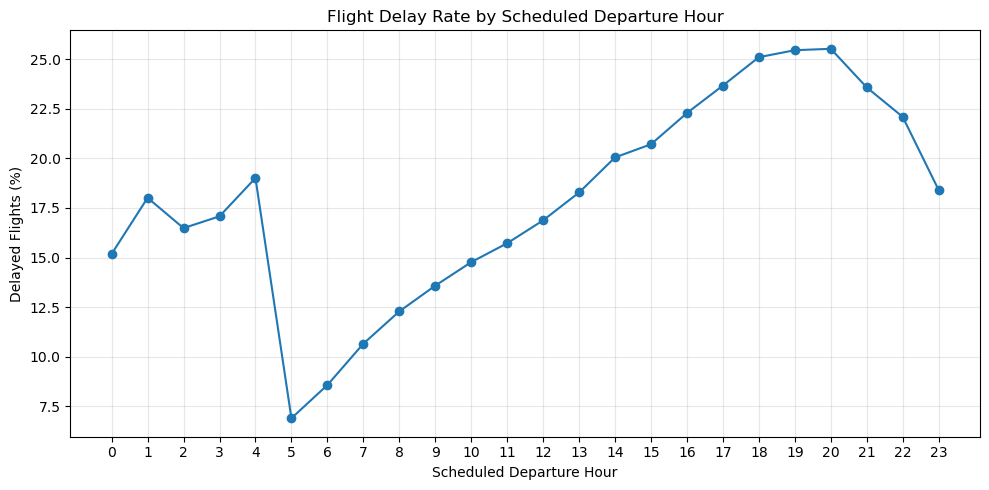

In [29]:
plt.figure(figsize=(10, 5))

plt.plot(
    hourly_delay.index,
    hourly_delay.values,
    marker="o"
)

plt.title("Flight Delay Rate by Scheduled Departure Hour")
plt.xlabel("Scheduled Departure Hour")
plt.ylabel("Delayed Flights (%)")

plt.xticks(range(24))
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Average arrival delay by airline

In [30]:
avg_delay_airline = (
    model_df.groupby("AIRLINE")["ARRIVAL_DELAY"]
    .mean()
    .sort_values(ascending=False)
)

print(avg_delay_airline.round(2))

AIRLINE
NK    14.47
F9    12.50
B6     6.68
EV     6.59
MQ     6.46
OO     5.85
UA     5.43
VX     4.74
WN     4.37
US     3.71
AA     3.45
HA     2.02
DL     0.19
AS    -0.98
Name: ARRIVAL_DELAY, dtype: float64


Visualize average delay by airline

In [32]:
avg_delay_airline = (
    model_df.groupby("AIRLINE")["ARRIVAL_DELAY"]
    .mean()
    .reset_index(name="AVG_ARRIVAL_DELAY")
)

avg_delay_airline = avg_delay_airline.merge(
    airlines,
    left_on="AIRLINE",
    right_on="IATA_CODE"
)

avg_delay_airline = avg_delay_airline.sort_values(
    "AVG_ARRIVAL_DELAY",
    ascending=False
)

avg_delay_airline

,AIRLINE_x,AVG_ARRIVAL_DELAY,IATA_CODE,AIRLINE_y
8,NK,14.471800,NK,Spirit Air Lines
5,F9,12.504706,F9,Frontier Airlines Inc.
2,B6,6.677861,B6,JetBlue Airways
4,EV,6.585379,EV,Atlantic Southeast Airlines
7,MQ,6.457873,MQ,American Eagle Airlines Inc.
9,OO,5.845652,OO,Skywest Airlines Inc.
10,UA,5.431594,UA,United Air Lines Inc.
12,VX,4.737706,VX,Virgin America
13,WN,4.374964,WN,Southwest Airlines Co.
11,US,3.706209,US,US Airways Inc.


In [34]:
avg_delay_airline = avg_delay_airline.rename(
    columns={
        "AIRLINE_x": "IATA_CODE",
        "AIRLINE_y": "AIRLINE_NAME"
    }
)

avg_delay_airline

,IATA_CODE,AVG_ARRIVAL_DELAY,IATA_CODE,AIRLINE_NAME
8,NK,14.471800,NK,Spirit Air Lines
5,F9,12.504706,F9,Frontier Airlines Inc.
2,B6,6.677861,B6,JetBlue Airways
4,EV,6.585379,EV,Atlantic Southeast Airlines
7,MQ,6.457873,MQ,American Eagle Airlines Inc.
9,OO,5.845652,OO,Skywest Airlines Inc.
10,UA,5.431594,UA,United Air Lines Inc.
12,VX,4.737706,VX,Virgin America
13,WN,4.374964,WN,Southwest Airlines Co.
11,US,3.706209,US,US Airways Inc.


In [36]:
avg_delay_airline = avg_delay_airline[
    ["IATA_CODE", "AIRLINE_NAME", "AVG_ARRIVAL_DELAY"]
]

avg_delay_airline

,IATA_CODE,IATA_CODE,AIRLINE_NAME,AVG_ARRIVAL_DELAY
8,NK,NK,Spirit Air Lines,14.471800
5,F9,F9,Frontier Airlines Inc.,12.504706
2,B6,B6,JetBlue Airways,6.677861
4,EV,EV,Atlantic Southeast Airlines,6.585379
7,MQ,MQ,American Eagle Airlines Inc.,6.457873
9,OO,OO,Skywest Airlines Inc.,5.845652
10,UA,UA,United Air Lines Inc.,5.431594
12,VX,VX,Virgin America,4.737706
13,WN,WN,Southwest Airlines Co.,4.374964
11,US,US,US Airways Inc.,3.706209


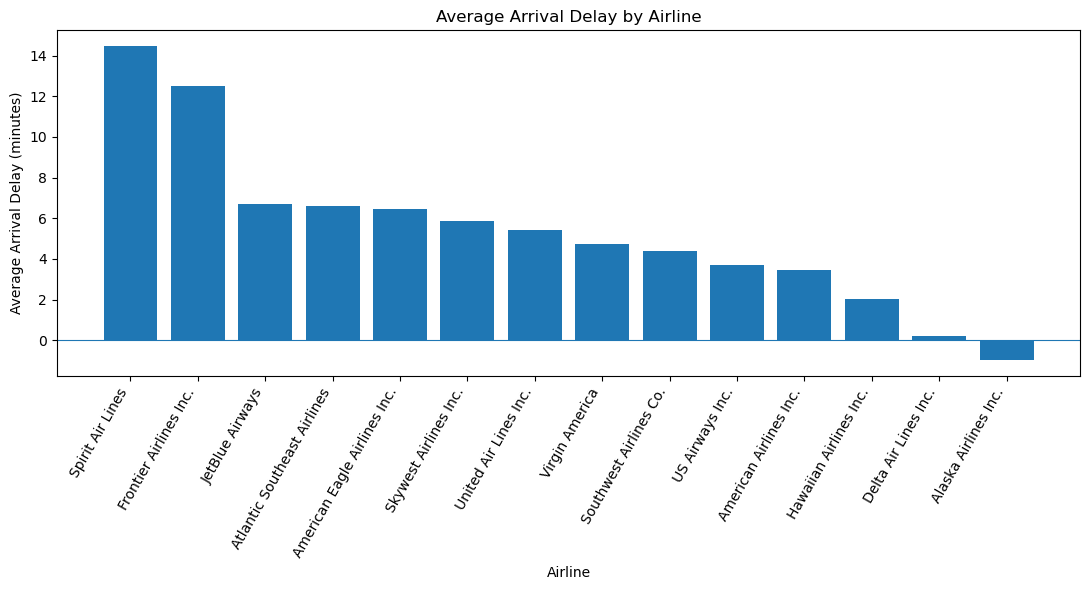

In [37]:
plt.figure(figsize=(11, 6))

plt.bar(
    avg_delay_airline["AIRLINE_NAME"],
    avg_delay_airline["AVG_ARRIVAL_DELAY"]
)

plt.axhline(0, linewidth=0.8)

plt.title("Average Arrival Delay by Airline")
plt.xlabel("Airline")
plt.ylabel("Average Arrival Delay (minutes)")

plt.xticks(rotation=60, ha="right")
plt.tight_layout()
plt.show()

Airport-level analysis

In [38]:
airport_delay = (
    model_df.groupby("ORIGIN_AIRPORT")
    .agg(
        TOTAL_FLIGHTS=("IS_DELAYED", "size"),
        DELAY_RATE=("IS_DELAYED", "mean")
    )
)

airport_delay["DELAY_RATE"] = (
    airport_delay["DELAY_RATE"] * 100
)

airport_delay = airport_delay.sort_values(
    "DELAY_RATE",
    ascending=False
)

airport_delay.head(20)

,TOTAL_FLIGHTS,DELAY_RATE
ORIGIN_AIRPORT,,
11097,1,100.000000
10165,9,55.555556
12206,14,50.000000
10581,2,50.000000
14222,8,50.000000
12915,9,44.444444
GST,76,43.421053
11140,19,42.105263
10279,17,41.176471


Filter airports with enough flights

In [39]:
airport_delay_reliable = airport_delay[
    airport_delay["TOTAL_FLIGHTS"] >= 1000
].copy()

airport_delay_reliable = airport_delay_reliable.sort_values(
    "DELAY_RATE",
    ascending=False
)

airport_delay_reliable.head(20)

,TOTAL_FLIGHTS,DELAY_RATE
ORIGIN_AIRPORT,,
ASE,3263,28.899785
11298,1137,28.759894
HPN,7132,23.906338
ORD,276554,23.378798
EGE,1198,23.372287
LGA,94834,23.246937
LBE,1245,23.212851
TTN,2771,23.204619
ACV,1268,22.397476


In [41]:
airports = pd.read_csv("../data/airports.csv")

airports.head()

,IATA_CODE,AIRPORT,CITY,STATE,COUNTRY,LATITUDE,LONGITUDE
0,ABE,Lehigh Valley International Airport,Allentown,PA,USA,40.65236,-75.44040
1,ABI,Abilene Regional Airport,Abilene,TX,USA,32.41132,-99.68190
2,ABQ,Albuquerque International Sunport,Albuquerque,NM,USA,35.04022,-106.60919
3,ABR,Aberdeen Regional Airport,Aberdeen,SD,USA,45.44906,-98.42183
4,ABY,Southwest Georgia Regional Airport,Albany,GA,USA,31.53552,-84.19447


In [42]:
airports.columns

Index(['IATA_CODE', 'AIRPORT', 'CITY', 'STATE', 'COUNTRY', 'LATITUDE',
       'LONGITUDE'],
      dtype='object')

Rename the Airport name column

In [43]:
airports_lookup = airports.rename(
    columns={
        "AIRPORT": "AIRPORT_NAME"
    }
)

airports_lookup.head()

,IATA_CODE,AIRPORT_NAME,CITY,STATE,COUNTRY,LATITUDE,LONGITUDE
0,ABE,Lehigh Valley International Airport,Allentown,PA,USA,40.65236,-75.44040
1,ABI,Abilene Regional Airport,Abilene,TX,USA,32.41132,-99.68190
2,ABQ,Albuquerque International Sunport,Albuquerque,NM,USA,35.04022,-106.60919
3,ABR,Aberdeen Regional Airport,Aberdeen,SD,USA,45.44906,-98.42183
4,ABY,Southwest Georgia Regional Airport,Albany,GA,USA,31.53552,-84.19447


Merge with our reliable airport table

In [44]:
airport_delay_reliable = airport_delay_reliable.reset_index()

airport_delay_reliable = airport_delay_reliable.merge(
    airports_lookup[["IATA_CODE", "AIRPORT_NAME", "CITY", "STATE"]],
    left_on="ORIGIN_AIRPORT",
    right_on="IATA_CODE",
    how="left"
)

airport_delay_reliable.head(20)

,ORIGIN_AIRPORT,TOTAL_FLIGHTS,DELAY_RATE,IATA_CODE,AIRPORT_NAME,CITY,STATE
0,ASE,3263,28.899785,ASE,Aspen-Pitkin County Airport,Aspen,CO
1,11298,1137,28.759894,NaN,NaN,NaN,NaN
2,HPN,7132,23.906338,HPN,Westchester County Airport,White Plains,NY
3,ORD,276554,23.378798,ORD,Chicago O'Hare International Airport,Chicago,IL
4,EGE,1198,23.372287,EGE,Eagle County Regional Airport,Eagle,CO
5,LGA,94834,23.246937,LGA,LaGuardia Airport (Marine Air Terminal),New York,NY
6,LBE,1245,23.212851,LBE,Arnold Palmer Regional Airport,Latrobe,PA
7,TTN,2771,23.204619,TTN,Trenton Mercer Airport,Trenton,NJ
8,ACV,1268,22.397476,ACV,Arcata Airport,Arcata/Eureka,CA
9,MIA,68301,22.371561,MIA,Miami International Airport,Miami,FL


top 15 high-volume airports

In [45]:
airport_delay_named = airport_delay_reliable.dropna(
    subset=["AIRPORT_NAME"]
).copy()

airport_delay_named = airport_delay_named.head(15)

airport_delay_named[
    ["ORIGIN_AIRPORT", "AIRPORT_NAME", "CITY", "STATE",
     "TOTAL_FLIGHTS", "DELAY_RATE"]
]

,ORIGIN_AIRPORT,AIRPORT_NAME,CITY,STATE,TOTAL_FLIGHTS,DELAY_RATE
0,ASE,Aspen-Pitkin County Airport,Aspen,CO,3263,28.899785
2,HPN,Westchester County Airport,White Plains,NY,7132,23.906338
3,ORD,Chicago O'Hare International Airport,Chicago,IL,276554,23.378798
4,EGE,Eagle County Regional Airport,Eagle,CO,1198,23.372287
5,LGA,LaGuardia Airport (Marine Air Terminal),New York,NY,94834,23.246937
6,LBE,Arnold Palmer Regional Airport,Latrobe,PA,1245,23.212851
7,TTN,Trenton Mercer Airport,Trenton,NJ,2771,23.204619
8,ACV,Arcata Airport,Arcata/Eureka,CA,1268,22.397476
9,MIA,Miami International Airport,Miami,FL,68301,22.371561
10,CRW,Yeager Airport,Charleston,WV,2315,22.332613


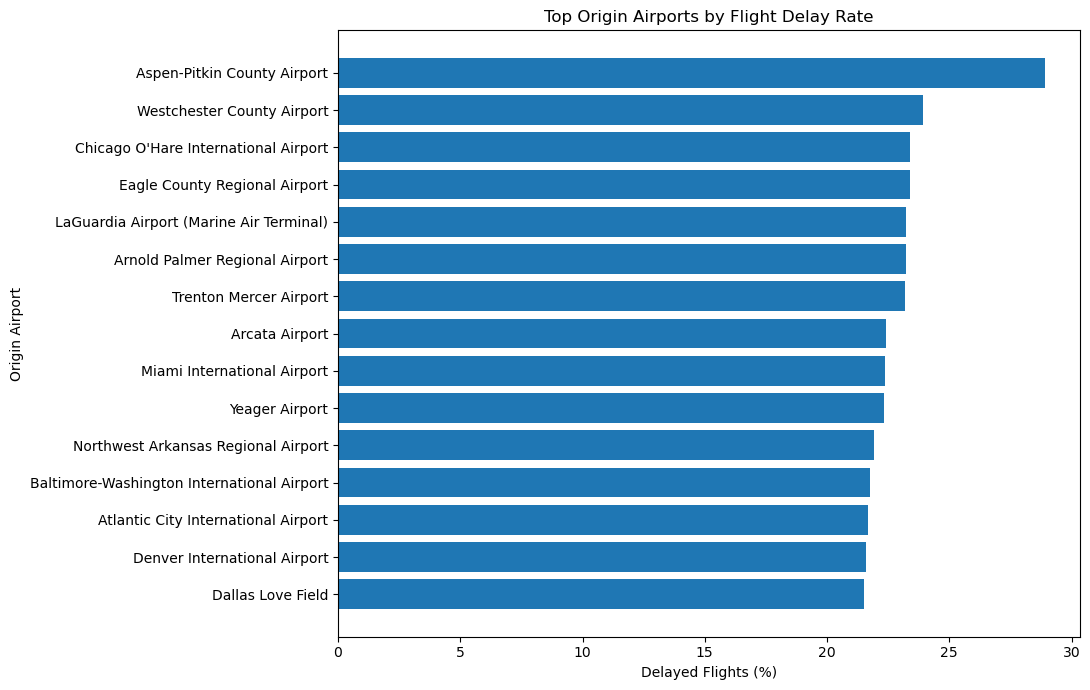

In [46]:
plt.figure(figsize=(11, 7))

plt.barh(
    airport_delay_named["AIRPORT_NAME"],
    airport_delay_named["DELAY_RATE"]
)

plt.title("Top Origin Airports by Flight Delay Rate")
plt.xlabel("Delayed Flights (%)")
plt.ylabel("Origin Airport")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

ML Preparation

Select pre-departure features

In [47]:
features_df = model_df[
    [
        "YEAR",
        "MONTH",
        "DAY_OF_WEEK",
        "SCHEDULED_DEPARTURE",
        "SCHEDULED_ARRIVAL",
        "SCHEDULED_TIME",
        "DISTANCE",
        "AIRLINE",
        "ORIGIN_AIRPORT",
        "DESTINATION_AIRPORT",
        "IS_DELAYED"
    ]
].copy()

features_df.head()

,YEAR,MONTH,DAY_OF_WEEK,SCHEDULED_DEPARTURE,SCHEDULED_ARRIVAL,SCHEDULED_TIME,DISTANCE,AIRLINE,ORIGIN_AIRPORT,DESTINATION_AIRPORT,IS_DELAYED
0,2015,1,4,5,430,205.0,1448,AS,ANC,SEA,0
1,2015,1,4,10,750,280.0,2330,AA,LAX,PBI,0
2,2015,1,4,20,806,286.0,2296,US,SFO,CLT,0
3,2015,1,4,20,805,285.0,2342,AA,LAX,MIA,0
4,2015,1,4,25,320,235.0,1448,AS,SEA,ANC,0


In [48]:
features_df["DEPARTURE_HOUR"] = (
    features_df["SCHEDULED_DEPARTURE"] // 100
)

features_df.head()

,YEAR,MONTH,DAY_OF_WEEK,SCHEDULED_DEPARTURE,SCHEDULED_ARRIVAL,SCHEDULED_TIME,DISTANCE,AIRLINE,ORIGIN_AIRPORT,DESTINATION_AIRPORT,IS_DELAYED,DEPARTURE_HOUR
0,2015,1,4,5,430,205.0,1448,AS,ANC,SEA,0,0
1,2015,1,4,10,750,280.0,2330,AA,LAX,PBI,0,0
2,2015,1,4,20,806,286.0,2296,US,SFO,CLT,0,0
3,2015,1,4,20,805,285.0,2342,AA,LAX,MIA,0,0
4,2015,1,4,25,320,235.0,1448,AS,SEA,ANC,0,0


Create the final feature set

In [49]:
X = features_df[
    [
        "YEAR",
        "MONTH",
        "DAY_OF_WEEK",
        "DEPARTURE_HOUR",
        "SCHEDULED_ARRIVAL",
        "SCHEDULED_TIME",
        "DISTANCE",
        "AIRLINE",
        "ORIGIN_AIRPORT",
        "DESTINATION_AIRPORT"
    ]
].copy()

y = features_df["IS_DELAYED"].copy()

print("Features shape:", X.shape)
print("Target shape:", y.shape)

X.head()

Features shape: (5714008, 10)
Target shape: (5714008,)


,YEAR,MONTH,DAY_OF_WEEK,DEPARTURE_HOUR,SCHEDULED_ARRIVAL,SCHEDULED_TIME,DISTANCE,AIRLINE,ORIGIN_AIRPORT,DESTINATION_AIRPORT
0,2015,1,4,0,430,205.0,1448,AS,ANC,SEA
1,2015,1,4,0,750,280.0,2330,AA,LAX,PBI
2,2015,1,4,0,806,286.0,2296,US,SFO,CLT
3,2015,1,4,0,805,285.0,2342,AA,LAX,MIA
4,2015,1,4,0,320,235.0,1448,AS,SEA,ANC


Check categorical and numerical features

In [50]:
print(X.dtypes)

YEAR                     int64
MONTH                    int64
DAY_OF_WEEK              int64
DEPARTURE_HOUR           int64
SCHEDULED_ARRIVAL        int64
SCHEDULED_TIME         float64
DISTANCE                 int64
AIRLINE                 object
ORIGIN_AIRPORT          object
DESTINATION_AIRPORT     object
dtype: object


In [51]:
print("\nUnique values:")
print(X.nunique())


Unique values:
YEAR                      1
MONTH                    12
DAY_OF_WEEK               7
DEPARTURE_HOUR           24
SCHEDULED_ARRIVAL      1434
SCHEDULED_TIME          549
DISTANCE               1350
AIRLINE                  14
ORIGIN_AIRPORT          929
DESTINATION_AIRPORT     929
dtype: int64


Create arrival hour and remove unnecessary columns

In [52]:
X["ARRIVAL_HOUR"] = X["SCHEDULED_ARRIVAL"] // 100

X = X.drop(
    columns=["YEAR", "SCHEDULED_ARRIVAL"]
)

print(X.dtypes)
print("\nShape:", X.shape)

MONTH                    int64
DAY_OF_WEEK              int64
DEPARTURE_HOUR           int64
SCHEDULED_TIME         float64
DISTANCE                 int64
AIRLINE                 object
ORIGIN_AIRPORT          object
DESTINATION_AIRPORT     object
ARRIVAL_HOUR             int64
dtype: object

Shape: (5714008, 9)


Train/test split

In [54]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True).mul(100).round(2))

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True).mul(100).round(2))

Training features: (4571206, 9)
Testing features: (1142802, 9)

Training target distribution:
IS_DELAYED
0    82.09
1    17.91
Name: proportion, dtype: float64

Testing target distribution:
IS_DELAYED
0    82.09
1    17.91
Name: proportion, dtype: float64


Standardize the categorical columns

In [57]:
categorical_features = [
    "AIRLINE",
    "ORIGIN_AIRPORT",
    "DESTINATION_AIRPORT"
]

X_train[categorical_features] = (
    X_train[categorical_features].astype(str)
)

X_test[categorical_features] = (
    X_test[categorical_features].astype(str)
)

print(X_train[categorical_features].dtypes)

AIRLINE                object
ORIGIN_AIRPORT         object
DESTINATION_AIRPORT    object
dtype: object


Build the preprocessing pipeline

In [58]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=True
            ),
            categorical_features
        ),
        (
            "numerical",
            "passthrough",
            numerical_features
        )
    ]
)

print("Preprocessor recreated successfully.")

Preprocessor recreated successfully.


Transform the training and test data

In [59]:
print("Transforming training data...")

X_train_encoded = preprocessor.fit_transform(X_train)

print("Training transformation complete.")
print("Training encoded shape:", X_train_encoded.shape)

print("\nTransforming test data...")

X_test_encoded = preprocessor.transform(X_test)

print("Test transformation complete.")
print("Test encoded shape:", X_test_encoded.shape)

Transforming training data...
Training transformation complete.
Training encoded shape: (4571206, 1277)

Transforming test data...
Test transformation complete.
Test encoded shape: (1142802, 1277)


Train our first model: Logistic Regression

In [60]:
from sklearn.linear_model import LogisticRegression

logreg = LogisticRegression(
    class_weight="balanced",
    max_iter=100,
    solver="saga",
    random_state=42
)

print("Training Logistic Regression...")

logreg.fit(X_train_encoded, y_train)

print("Logistic Regression training complete.")

Training Logistic Regression...
Logistic Regression training complete.


C:\Users\RENUKA\anaconda3\jupyter\Lib\site-packages\sklearn\linear_model\_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Evaluate Logistic Regression

In [61]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    roc_auc_score,
    confusion_matrix
)

print("Generating predictions...")

y_pred = logreg.predict(X_test_encoded)
y_pred_proba = logreg.predict_proba(X_test_encoded)[:, 1]

print("Predictions generated.")

print("\nLogistic Regression Results")
print("-" * 30)

print("Accuracy :", round(accuracy_score(y_test, y_pred), 4))
print("Precision:", round(precision_score(y_test, y_pred), 4))
print("Recall   :", round(recall_score(y_test, y_pred), 4))
print("ROC-AUC  :", round(roc_auc_score(y_test, y_pred_proba), 4))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Generating predictions...
Predictions generated.

Logistic Regression Results
------------------------------
Accuracy : 0.5675
Precision: 0.2354
Recall   : 0.6293
ROC-AUC  : 0.6212

Confusion Matrix:
[[519774 418328]
 [ 75879 128821]]


Check your available memory first

In [62]:
import psutil

memory = psutil.virtual_memory()

print("Total RAM:", round(memory.total / (1024**3), 2), "GB")
print("Available RAM:", round(memory.available / (1024**3), 2), "GB")

Total RAM: 11.83 GB
Available RAM: 0.79 GB


In [63]:
import gc

del df
del model_df
del features_df
del X
del X_train
del X_test

gc.collect()

print("Garbage collection complete.")

Garbage collection complete.


In [64]:
import psutil

memory = psutil.virtual_memory()

print("Available RAM:", round(memory.available / (1024**3), 2), "GB")

Available RAM: 1.95 GB


Create a manageable Random Forest training sample

In [65]:
from sklearn.model_selection import train_test_split

X_rf, _, y_rf, _ = train_test_split(
    X_train_encoded,
    y_train,
    train_size=500_000,
    random_state=42,
    stratify=y_train
)

print("Random Forest training shape:", X_rf.shape)
print("Random Forest target distribution:")
print(y_rf.value_counts(normalize=True).mul(100).round(2))

Random Forest training shape: (500000, 1277)
Random Forest target distribution:
IS_DELAYED
0    82.09
1    17.91
Name: proportion, dtype: float64


Train Random Forest

In [66]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=50,
    max_depth=12,
    min_samples_leaf=10,
    class_weight="balanced",
    n_jobs=2,
    random_state=42
)

print("Training Random Forest...")

rf.fit(X_rf, y_rf)

print("Random Forest training complete.")

Training Random Forest...
Random Forest training complete.


Evaluate Random Forest

In [67]:
print("Generating Random Forest predictions...")

rf_pred = rf.predict(X_test_encoded)
rf_pred_proba = rf.predict_proba(X_test_encoded)[:, 1]

print("Predictions generated.")

print("\nRandom Forest Results")
print("-" * 30)

print("Accuracy :", round(accuracy_score(y_test, rf_pred), 4))
print("Precision:", round(precision_score(y_test, rf_pred), 4))
print("Recall   :", round(recall_score(y_test, rf_pred), 4))
print("ROC-AUC  :", round(roc_auc_score(y_test, rf_pred_proba), 4))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, rf_pred))

Generating Random Forest predictions...
Predictions generated.

Random Forest Results
------------------------------
Accuracy : 0.591
Precision: 0.247
Recall   : 0.6264
ROC-AUC  : 0.646

Confusion Matrix:
[[547193 390909]
 [ 76484 128216]]


inspect the classification report

In [68]:
from sklearn.metrics import classification_report

print("Logistic Regression")
print("=" * 50)
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Not Delayed", "Delayed"]
    )
)

print("\nRandom Forest")
print("=" * 50)
print(
    classification_report(
        y_test,
        rf_pred,
        target_names=["Not Delayed", "Delayed"]
    )
)

Logistic Regression
              precision    recall  f1-score   support

 Not Delayed       0.87      0.55      0.68    938102
     Delayed       0.24      0.63      0.34    204700

    accuracy                           0.57   1142802
   macro avg       0.55      0.59      0.51   1142802
weighted avg       0.76      0.57      0.62   1142802


Random Forest
              precision    recall  f1-score   support

 Not Delayed       0.88      0.58      0.70    938102
     Delayed       0.25      0.63      0.35    204700

    accuracy                           0.59   1142802
   macro avg       0.56      0.60      0.53   1142802
weighted avg       0.76      0.59      0.64   1142802



Explore the classification threshold

In [69]:
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = [0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60, 0.65, 0.70]

print("Threshold | Precision | Recall | F1")
print("-" * 40)

for threshold in thresholds:
    predictions = (rf_pred_proba >= threshold).astype(int)

    precision = precision_score(y_test, predictions)
    recall = recall_score(y_test, predictions)
    f1 = f1_score(y_test, predictions)

    print(
        f"{threshold:>9.2f} | "
        f"{precision:>9.4f} | "
        f"{recall:>6.4f} | "
        f"{f1:>6.4f}"
    )

Threshold | Precision | Recall | F1
----------------------------------------
     0.30 |    0.1792 | 0.9999 | 0.3040
     0.35 |    0.1795 | 0.9996 | 0.3043
     0.40 |    0.1807 | 0.9960 | 0.3059
     0.45 |    0.2033 | 0.9042 | 0.3319
     0.50 |    0.2470 | 0.6264 | 0.3543
     0.55 |    0.3270 | 0.1793 | 0.2316
     0.60 |    0.4664 | 0.0048 | 0.0095


C:\Users\RENUKA\anaconda3\jupyter\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


     0.65 |    0.0000 | 0.0000 | 0.0000


C:\Users\RENUKA\anaconda3\jupyter\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


     0.70 |    0.0000 | 0.0000 | 0.0000


In [70]:
#  Feature Engineering

# Work from the existing training/test data
X_train_fe = X_train_encoded
X_test_fe = X_test_encoded

print("Current encoded training shape:", X_train_fe.shape)
print("Current encoded test shape:", X_test_fe.shape)

Current encoded training shape: (4571206, 1277)
Current encoded test shape: (1142802, 1277)


In [71]:
# Random Forest Feature Importance

import numpy as np

feature_importance = rf.feature_importances_

print("Number of features:", len(feature_importance))
print("Highest importance:", feature_importance.max())
print("Lowest importance:", feature_importance.min())
print("Mean importance:", feature_importance.mean())

Number of features: 1277
Highest importance: 0.2254345020383447
Lowest importance: 0.0
Mean importance: 0.0007830853563038371


In [72]:
# Top 20 feature importance values

top_indices = np.argsort(feature_importance)[-20:][::-1]

print("Top 20 feature indices and importance:")
for rank, idx in enumerate(top_indices, start=1):
    print(f"{rank:2d}. Feature {idx:4d} → {feature_importance[idx]:.6f}")

Top 20 feature indices and importance:
 1. Feature 1276 → 0.225435
 2. Feature 1273 → 0.205251
 3. Feature 1271 → 0.085110
 4. Feature    3 → 0.051094
 5. Feature 1274 → 0.031063
 6. Feature 1131 → 0.030071
 7. Feature  548 → 0.027202
 8. Feature    8 → 0.027169
 9. Feature 1272 → 0.024038
10. Feature    1 → 0.022106
11. Feature    2 → 0.018837
12. Feature 1275 → 0.015841
13. Feature  461 → 0.010767
14. Feature    6 → 0.008547
15. Feature    5 → 0.008308
16. Feature   10 → 0.007841
17. Feature  661 → 0.007664
18. Feature  969 → 0.007609
19. Feature  606 → 0.007040
20. Feature 1235 → 0.007032


In [74]:
#  Map encoded features to their original names

feature_names = preprocessor.get_feature_names_out()

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf.feature_importances_
})

importance_df = importance_df.sort_values(
    "Importance",
    ascending=False
)

print(importance_df.head(20).to_string(index=False))

                               Feature  Importance
               numerical__ARRIVAL_HOUR    0.225435
             numerical__DEPARTURE_HOUR    0.205251
                      numerical__MONTH    0.085110
               categorical__AIRLINE_DL    0.051094
             numerical__SCHEDULED_TIME    0.031063
  categorical__DESTINATION_AIRPORT_LGA    0.030071
       categorical__ORIGIN_AIRPORT_ORD    0.027202
               categorical__AIRLINE_NK    0.027169
                numerical__DAY_OF_WEEK    0.024038
               categorical__AIRLINE_AS    0.022106
               categorical__AIRLINE_B6    0.018837
                   numerical__DISTANCE    0.015841
       categorical__ORIGIN_AIRPORT_HNL    0.010767
               categorical__AIRLINE_HA    0.008547
               categorical__AIRLINE_F9    0.008308
               categorical__AIRLINE_UA    0.007841
categorical__DESTINATION_AIRPORT_10397    0.007664
  categorical__DESTINATION_AIRPORT_ATL    0.007609
       categorical__ORIGIN_AIRP

Create a smaller experimental dataset

In [75]:
import os

file_path = "../data/flights.csv"

print("File exists:", os.path.exists(file_path))

if os.path.exists(file_path):
    print("File size (GB):", round(os.path.getsize(file_path) / (1024**3), 2))

File exists: True
File size (GB): 0.55


Build a memory-efficient feature sample

In [76]:
#  Create a memory-efficient sample for feature engineering

import pandas as pd
import numpy as np
import gc

file_path = "../data/flights.csv"

# Features needed for our experiment
columns_needed = [
    "YEAR",
    "MONTH",
    "DAY_OF_WEEK",
    "SCHEDULED_DEPARTURE",
    "SCHEDULED_ARRIVAL",
    "SCHEDULED_TIME",
    "DISTANCE",
    "AIRLINE",
    "ORIGIN_AIRPORT",
    "DESTINATION_AIRPORT",
    "ARRIVAL_DELAY",
    "CANCELLED",
    "DIVERTED"
]

target_sample_size = 500_000
chunks = []
rows_collected = 0

for chunk in pd.read_csv(
    file_path,
    usecols=columns_needed,
    chunksize=200_000,
    low_memory=False
):
    # Keep only usable flights
    chunk = chunk[
        (chunk["CANCELLED"] == 0) &
        (chunk["DIVERTED"] == 0) &
        (chunk["ARRIVAL_DELAY"].notna())
    ].copy()

    if len(chunk) == 0:
        continue

    # How many more rows do we need?
    remaining = target_sample_size - rows_collected

    if len(chunk) > remaining:
        chunk = chunk.sample(
            n=remaining,
            random_state=42
        )

    chunks.append(chunk)
    rows_collected += len(chunk)

    print(f"Rows collected: {rows_collected:,}")

    if rows_collected >= target_sample_size:
        break

sample_df = pd.concat(chunks, ignore_index=True)

# Create target
sample_df["IS_DELAYED"] = (
    sample_df["ARRIVAL_DELAY"] > 15
).astype("int8")

print("\nFinal sample shape:", sample_df.shape)
print("\nTarget distribution:")
print(sample_df["IS_DELAYED"].value_counts(normalize=True).sort_index())

Rows collected: 194,401
Rows collected: 390,064
Rows collected: 500,000

Final sample shape: (500000, 14)

Target distribution:
IS_DELAYED
0    0.793886
1    0.206114
Name: proportion, dtype: float64


In [77]:
#  Feature Engineering

# Make a copy so the raw sample remains available
fe_df = sample_df.copy()

# -----------------------------
# 1. Time-based features
# -----------------------------

fe_df["DEPARTURE_HOUR"] = (
    fe_df["SCHEDULED_DEPARTURE"] // 100
).astype("int8")

fe_df["ARRIVAL_HOUR"] = (
    fe_df["SCHEDULED_ARRIVAL"] // 100
).astype("int8")

# Weekend indicator
fe_df["IS_WEEKEND"] = (
    fe_df["DAY_OF_WEEK"].isin([6, 7])
).astype("int8")

# Peak departure hours
fe_df["IS_PEAK_DEPARTURE"] = (
    fe_df["DEPARTURE_HOUR"].between(7, 10) |
    fe_df["DEPARTURE_HOUR"].between(16, 20)
).astype("int8")

# -----------------------------
# 2. Route feature
# -----------------------------

fe_df["ROUTE"] = (
    fe_df["ORIGIN_AIRPORT"].astype(str)
    + "_"
    + fe_df["DESTINATION_AIRPORT"].astype(str)
)

# -----------------------------
# 3. Distance category
# -----------------------------

fe_df["DISTANCE_CATEGORY"] = pd.cut(
    fe_df["DISTANCE"],
    bins=[0, 500, 1500, 3000, np.inf],
    labels=["Short", "Medium", "Long", "Very_Long"]
)

# -----------------------------
# 4. Scheduled duration category
# -----------------------------

fe_df["SCHEDULED_TIME_CATEGORY"] = pd.cut(
    fe_df["SCHEDULED_TIME"],
    bins=[0, 90, 180, 300, np.inf],
    labels=["Short", "Medium", "Long", "Very_Long"]
)

# -----------------------------
# Check the result
# -----------------------------

print("Feature-engineered shape:", fe_df.shape)

print("\nNew features:")
print([
    "DEPARTURE_HOUR",
    "ARRIVAL_HOUR",
    "IS_WEEKEND",
    "IS_PEAK_DEPARTURE",
    "ROUTE",
    "DISTANCE_CATEGORY",
    "SCHEDULED_TIME_CATEGORY"
])

print("\nSample:")
print(
    fe_df[
        [
            "AIRLINE",
            "ORIGIN_AIRPORT",
            "DESTINATION_AIRPORT",
            "ROUTE",
            "DEPARTURE_HOUR",
            "ARRIVAL_HOUR",
            "IS_WEEKEND",
            "IS_PEAK_DEPARTURE",
            "DISTANCE_CATEGORY",
            "SCHEDULED_TIME_CATEGORY",
            "IS_DELAYED"
        ]
    ].head()
)

Feature-engineered shape: (500000, 21)

New features:
['DEPARTURE_HOUR', 'ARRIVAL_HOUR', 'IS_WEEKEND', 'IS_PEAK_DEPARTURE', 'ROUTE', 'DISTANCE_CATEGORY', 'SCHEDULED_TIME_CATEGORY']

Sample:
  AIRLINE ORIGIN_AIRPORT DESTINATION_AIRPORT    ROUTE  DEPARTURE_HOUR  \
0      AS            ANC                 SEA  ANC_SEA               0   
1      AA            LAX                 PBI  LAX_PBI               0   
2      US            SFO                 CLT  SFO_CLT               0   
3      AA            LAX                 MIA  LAX_MIA               0   
4      AS            SEA                 ANC  SEA_ANC               0   

   ARRIVAL_HOUR  IS_WEEKEND  IS_PEAK_DEPARTURE DISTANCE_CATEGORY  \
0             4           0                  0            Medium   
1             7           0                  0              Long   
2             8           0                  0              Long   
3             8           0                  0              Long   
4             3           0    